# 08 · Seller & category performance

Which categories and sellers drive revenue vs. drag down satisfaction,
including a "revenue at risk" seller list (top-quartile revenue,
below-median review score).

In [1]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
RESULTS = ROOT / "results"
MIN_ORDERS_SELLER = 30  # sellers with fewer orders are too noisy to rank

In [2]:
orders = pd.read_parquet(PROCESSED / "orders_clean.parquet")
items = pd.read_parquet(PROCESSED / "order_items_clean.parquet")

delivered_ids = set(orders.loc[orders["order_status"] == "delivered", "order_id"])
items_d = items[items["order_id"].isin(delivered_ids)].copy()

review_map = orders.set_index("order_id")["review_score"]
late_map = orders.set_index("order_id")["is_late"]
items_d["review_score"] = items_d["order_id"].map(review_map)
items_d["is_late"] = items_d["order_id"].map(late_map)

## Category performance

In [3]:
cat_perf = items_d.groupby("product_category_name_english").agg(
    revenue=("price", "sum"),
    n_orders=("order_id", "nunique"),
    n_items=("order_item_id", "count"),
    avg_price=("price", "mean"),
    avg_review_score=("review_score", "mean"),
    pct_late=("is_late", lambda s: s.mean() * 100),
).reset_index().rename(columns={"product_category_name_english": "category"})
cat_perf = cat_perf.sort_values("revenue", ascending=False)
cat_perf.to_csv(RESULTS / "category_performance.csv", index=False)

top10_revenue_cats = cat_perf.head(10)
sizable_cats = cat_perf[cat_perf["n_orders"] >= 100]
worst_review_cats = sizable_cats.sort_values("avg_review_score").head(10)

print("Top 10 categories by revenue:")
print(top10_revenue_cats[["category", "revenue", "n_orders", "avg_review_score"]].to_string(index=False))
print("\nWorst 10 categories by avg review score (min 100 orders):")
print(worst_review_cats[["category", "revenue", "n_orders", "avg_review_score", "pct_late"]].to_string(index=False))

Top 10 categories by revenue:
             category    revenue  n_orders  avg_review_score
        health_beauty 1233131.72      8647          4.174855
        watches_gifts 1166176.98      5495          4.055982
       bed_bath_table 1023434.76      9272          3.900758
       sports_leisure  954852.55      7530          4.151821
computers_accessories  888724.61      6530          3.978545
      furniture_decor  711927.69      6307          3.937500
           housewares  615628.69      5743          4.093157
           cool_stuff  610204.10      3559          4.183163
                 auto  578966.65      3810          4.089614
                 toys  471286.48      3804          4.189330

Worst 10 categories by avg review score (min 100 orders):
             category    revenue  n_orders  avg_review_score  pct_late
     office_furniture  268154.31      1254          3.507194  8.932854
fashion_male_clothing   10452.33       106          3.736000  5.600000
      fixed_telephony   553

## Seller performance

In [4]:
seller_perf = items_d.groupby("seller_id").agg(
    revenue=("price", "sum"),
    n_orders=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    pct_late=("is_late", lambda s: s.mean() * 100),
    seller_state=("seller_state", "first"),
).reset_index()
seller_perf = seller_perf.sort_values("revenue", ascending=False)
seller_perf.to_csv(RESULTS / "seller_performance.csv", index=False)

qualified = seller_perf[seller_perf["n_orders"] >= MIN_ORDERS_SELLER]
top10_sellers = qualified.head(10)
revenue_at_risk = qualified[
    (qualified["avg_review_score"] < qualified["avg_review_score"].median())
    & (qualified["revenue"] >= qualified["revenue"].quantile(0.75))
].sort_values("revenue", ascending=False)

print(f"Sellers with >= {MIN_ORDERS_SELLER} orders: {len(qualified):,} of {len(seller_perf):,} total")
total_revenue_at_risk = revenue_at_risk["revenue"].sum()
total_revenue_qualified = qualified["revenue"].sum()
print(f"'Revenue at risk' sellers: {len(revenue_at_risk)}, "
      f"R$ {total_revenue_at_risk:,.2f} ({total_revenue_at_risk/total_revenue_qualified*100:.1f}% "
      f"of qualified-seller revenue)")

Sellers with >= 30 orders: 627 of 2,970 total
'Revenue at risk' sellers: 83, R$ 3,854,394.13 (37.8% of qualified-seller revenue)


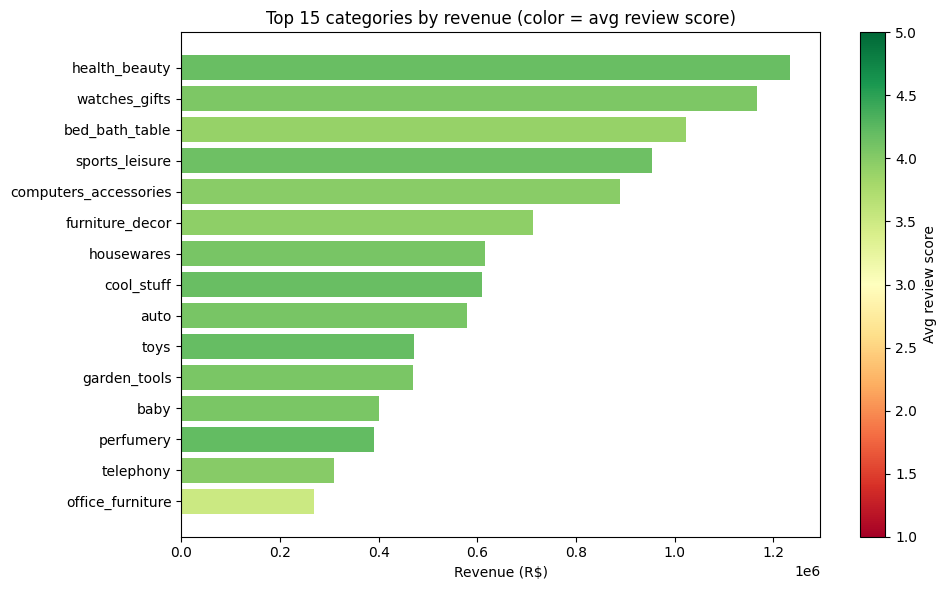

In [5]:
plt.figure(figsize=(10, 6))
top15 = cat_perf.head(15).sort_values("revenue")
colors = plt.cm.RdYlGn((top15["avg_review_score"] - 1) / 4)
plt.barh(top15["category"], top15["revenue"], color=colors)
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=plt.Normalize(1, 5))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Avg review score")
plt.xlabel("Revenue (R$)")
plt.title("Top 15 categories by revenue (color = avg review score)")
plt.tight_layout()
plt.show()

In [6]:
summary = {
    "top10_revenue_categories": top10_revenue_cats.to_dict(orient="records"),
    "worst10_review_categories_min100orders": worst_review_cats.to_dict(orient="records"),
    "n_qualified_sellers": int(len(qualified)),
    "n_total_sellers": int(len(seller_perf)),
    "top10_sellers_by_revenue": top10_sellers.to_dict(orient="records"),
    "n_revenue_at_risk_sellers": int(len(revenue_at_risk)),
    "revenue_at_risk_total": round(float(total_revenue_at_risk), 2),
    "revenue_at_risk_pct_of_qualified": round(float(total_revenue_at_risk / total_revenue_qualified * 100), 2),
}
with open(RESULTS / "seller_category_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

print("Saved: results/category_performance.csv, results/seller_performance.csv, "
      "results/seller_category_summary.json")

Saved: results/category_performance.csv, results/seller_performance.csv, results/seller_category_summary.json
